### Descargar el dataset.

### Preparamos los datos con ImageDataGenerator

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale =1./255)

train_dir = 'cats_and_dogs_filtered/train'
valid_dir = 'cats_and_dogs_filtered/validation'

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150,150),
    batch_size=20,
    class_mode='binary')

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(150,150),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [14]:
# Los índices serán los siguientes
# Para las imágenes de gatos (0) y
# para las imágenes de perros (1)

train_gen.class_indices

{'cats': 0, 'dogs': 1}

0.0


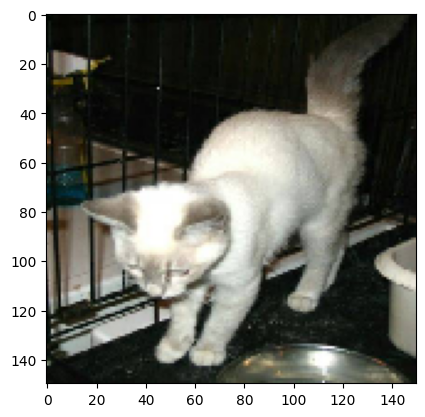

In [15]:
import matplotlib.pyplot as plt

batchX, batchY = next(train_gen)

plt.imshow(batchX[0])
print(batchY[0])

In [16]:
batchX.shape

(20, 150, 150, 3)

### Construimos y entrenamos el modelo

In [17]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.optimizers import RMSprop

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

In [18]:
opt = RMSprop(learning_rate=0.0001)

model.compile(loss='binary_crossentropy',
             optimizer=opt,
             metrics=['accuracy'])

In [19]:
hist = model.fit(train_gen, validation_data=valid_gen, epochs=30)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 312ms/step - accuracy: 0.5250 - loss: 0.6912 - val_accuracy: 0.5500 - val_loss: 0.6846
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - accuracy: 0.5740 - loss: 0.6723 - val_accuracy: 0.6010 - val_loss: 0.6546
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 285ms/step - accuracy: 0.6205 - loss: 0.6456 - val_accuracy: 0.6660 - val_loss: 0.6274
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 288ms/step - accuracy: 0.6570 - loss: 0.6133 - val_accuracy: 0.6300 - val_loss: 0.6222
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.7020 - loss: 0.5719 - val_accuracy: 0.6720 - val_loss: 0.6033
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.7130 - loss: 0.5549 - val_accuracy: 0.7050 - val_loss: 0.5724
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - accuracy: 0.7250 - loss: 0.5414 - val_accuracy: 0.7060 - val_loss: 0.5724
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 274ms/step - accuracy: 0.7330 - loss: 0

### Evaluamos

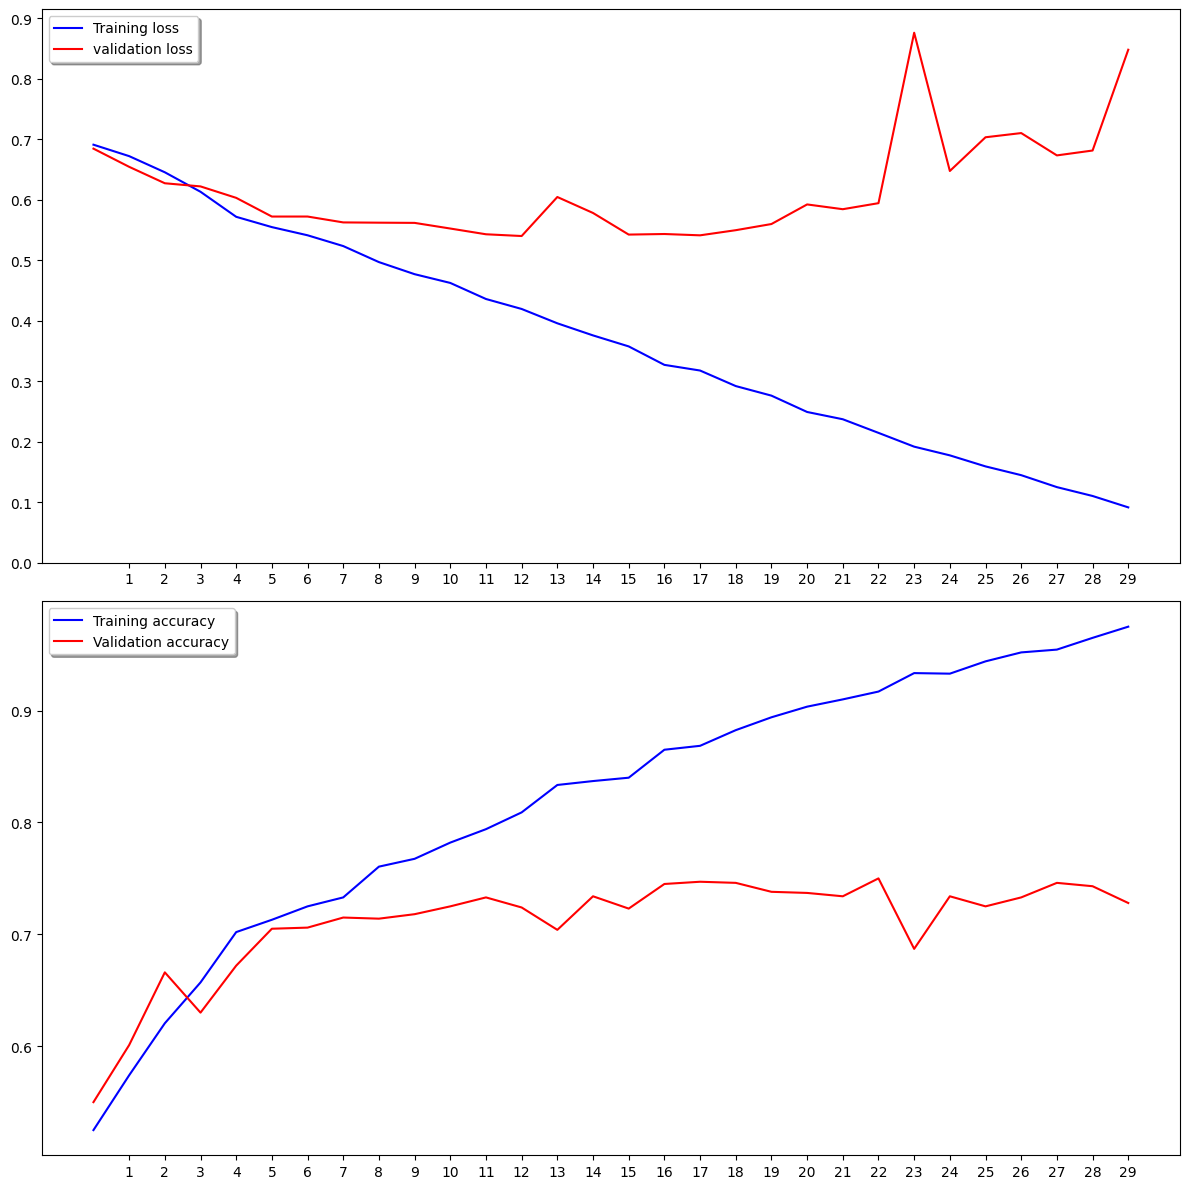

In [20]:
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(hist.history['loss'], color='b', label="Training loss")
ax1.plot(hist.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, 30, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))
ax1.legend(loc='best', shadow=True)

ax2.plot(hist.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(hist.history['val_accuracy'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, 30, 1))
ax2.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

# Técnica de Dataset aumentado

Ya hemos visto que el overfitting puede ser evitado si contamos con un conjunto de datos lo mayor posible. Si modificamos las imágenes de forma que sigan siendo representativas, pero que para el modelo sean nuevas, le ayudaremos a generalizar mejor.

### Trucos para aumentar el dataset:

1.- Rotación entre 0 y 180 grados

2.- Cambios de altura o anchura

3.- Recortes

4.- Aumentos

5.- Simetrías

Tras las transformaciones, también es útil la funcionalidad de añadir pixeles de relleno en las zonas que quedan vacías.

## Nuevo modelo con dropout

Definimos ahora una nueva red neuronal convolucional, añadiendo dropout tras el bloque convolucional

In [21]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

opt = RMSprop(learning_rate=0.0001)

model.compile(loss='binary_crossentropy',
             optimizer=opt,
             metrics=['accuracy'])

c:\Users\Bruno\Desktop\EjercicioRedesProfundas\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,)

valid_datagen = ImageDataGenerator(rescale =1./255)

train_dir = 'cats_and_dogs_filtered/train'
valid_dir = 'cats_and_dogs_filtered/validation'

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size= (150,150),
    batch_size=32,
    class_mode='binary')

valid_gen = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [23]:
hist = model.fit(train_gen, validation_data=valid_gen, epochs=100)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.5075 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6901
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 452ms/step - accuracy: 0.5270 - loss: 0.6890 - val_accuracy: 0.6120 - val_loss: 0.6802
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 461ms/step - accuracy: 0.5550 - loss: 0.6814 - val_accuracy: 0.5120 - val_loss: 0.6810
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 413ms/step - accuracy: 0.5670 - loss: 0.6782 - val_accuracy: 0.5560 - val_loss: 0.6768
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 423ms/step - accuracy: 0.5815 - loss: 0.6743 - val_accuracy: 0.5960 - val_loss: 0.6622
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 426ms/step - accuracy: 0.5850 - loss: 0.6712 - val_accuracy: 0.6120 - val_loss: 0.6481
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 392ms/step - accuracy: 0.5880 - loss: 0.6652 - val_accuracy: 0.6300 - val_loss: 0.6361
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 396ms/step - accuracy: 0.5975 - loss: 0.6598 - 

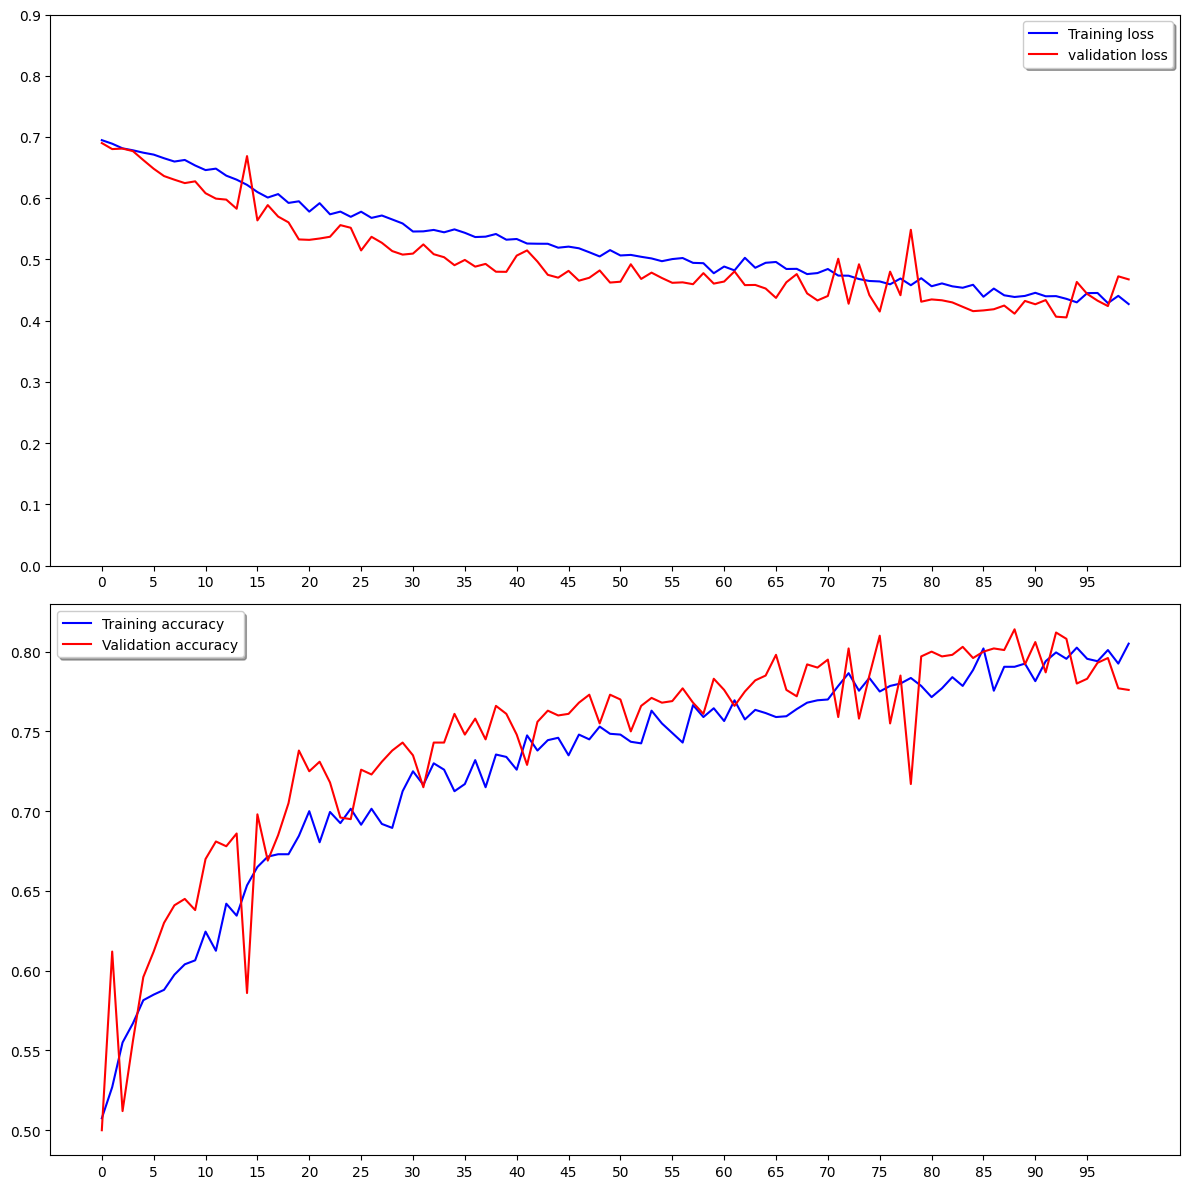

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(hist.history['loss'], color='b', label="Training loss")
ax1.plot(hist.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(0, 100, 5))
ax1.set_yticks(np.arange(0, 1, 0.1))
ax1.legend(loc='best', shadow=True)

ax2.plot(hist.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(hist.history['val_accuracy'], color='r',label="Validation accuracy") 
ax2.set_xticks(np.arange(0, 100, 5))
ax2.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()